Read the data in and start inspecting

In [84]:
import pandas as pd
import os 

filepath = os.path.join('..', 'data', 'train.csv')

df = pd.read_csv(filepath)

df.head(5)

,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X11,X12,X13,X14,X15,X16,X17,X18,X19,Y
0,256039,3600.0,a,7.37,b,a,b,62004.0,a,Feb-2009,...,3.50,6.0,0.0,5514.0,19.5,20.0,b,a,NaN,0
1,176486,12000.0,b,16.49,e,g,b,143000.0,a,Nov-2014,...,14.03,14.0,1.0,5808.0,75.4,36.0,a,a,1.0,0
2,392670,8500.0,b,11.49,a,b,b,27000.0,a,Jun-2010,...,0.89,12.0,0.0,449.0,2.0,22.0,b,a,NaN,1
3,46168,3725.0,a,10.99,a,l,a,14916.0,c,Nov-2015,...,32.42,14.0,0.0,6557.0,23.9,26.0,a,a,0.0,0
4,313821,28000.0,a,15.41,e,a,a,100000.0,b,Dec-2015,...,9.91,11.0,1.0,17499.0,53.2,29.0,b,a,0.0,1


I will start analysing features 10 - 19

In [85]:
features = df.iloc[:, 10:20]
features

,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19
0,f,3.50,6.0,0.0,5514.0,19.5,20.0,b,a,NaN
1,b,14.03,14.0,1.0,5808.0,75.4,36.0,a,a,1.0
2,d,0.89,12.0,0.0,449.0,2.0,22.0,b,a,NaN
3,b,32.42,14.0,0.0,6557.0,23.9,26.0,a,a,0.0
4,b,9.91,11.0,1.0,17499.0,53.2,29.0,b,a,0.0
...,...,...,...,...,...,...,...,...,...,...
316819,c,13.47,12.0,0.0,27925.0,24.6,23.0,b,a,NaN
316820,b,4.95,6.0,0.0,4724.0,53.1,17.0,b,a,2.0
316821,b,19.21,13.0,1.0,13113.0,55.3,23.0,b,a,2.0
316822,b,17.43,8.0,2.0,7008.0,96.0,25.0,b,a,5.0


In [86]:
target = df['Y']
target

0         0
1         0
2         1
3         0
4         1
         ..
316819    0
316820    1
316821    0
316822    0
316823    0
Name: Y, Length: 316824, dtype: int64

# X10

In [87]:
features['X10'].describe()

count     316824
unique        14
top            b
freq      187566
Name: X10, dtype: object

It is evident that 'X10' is a categorical feature with 14 unique values 

In [88]:
features['X10'].isnull().sum()

0

Thus there are no missing values for this variable

Let's have a look at the frequency distribution of 'X10'

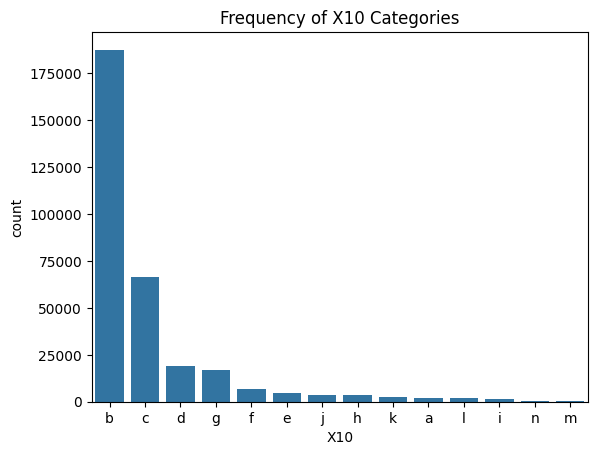

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# frequency of each category
x10_freq = features['X10'].value_counts()

# Bar plot
sns.countplot(data=features, x='X10', order=x10_freq.index)
plt.title('Frequency of X10 Categories')
plt.show()

We see that 'b' is a category that is extremely dominant with 'c' also being fairly dominant. Other categories such as 'a', 'l', 'i', 'n', 'm' are quite rare. 

Let's see how 'X10' relates with the target variable.

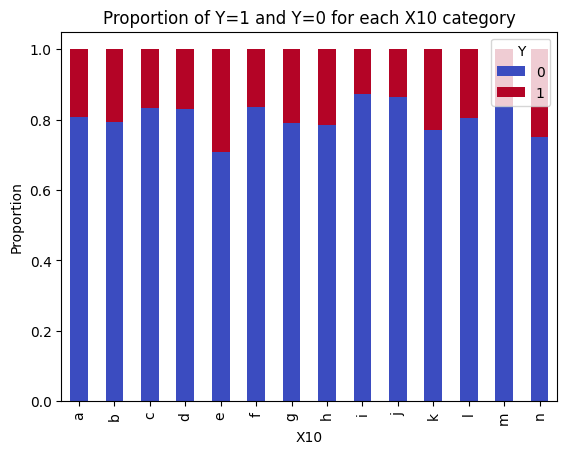

In [90]:
# We compute a cross-tabulation (contigency table) which allows to see how many Y=1 and Y=0
# each category of X10 has

# We've normalised the proportions since some categories such as 'b' are extremely dominant and would
# skew the plot. 
ct = pd.crosstab(features['X10'], target, normalize='index')

# We can then plot this crosstab using a stacked bar chart
ct.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Proportion of Y=1 and Y=0 for each X10 category')
plt.ylabel('Proportion')
plt.show()

It seems that most categories of 'X10' are heavily skewed towards Y=0 which is seen in blue. This most likely means the overall dataset has more instances of Y=0. Some categories such as 'e' have visibly higher proportions of Y=1 which is seen in red. Overall on its own, it doesn't seem like 'X10' is a dominant feature with strong predictive but could be meaningful when combined with others. 

# X11

In [91]:
features['X11'].describe()

count    316824.000000
mean         17.356240
std           8.649246
min           0.000000
25%          11.280000
50%          16.910000
75%          22.980000
max        1622.000000
Name: X11, dtype: float64

The mean of 'X11' seems to be around 17.4 however the maximum value is 1622 which seems like a massive outlier that will need to be dealt with. 

In [92]:
features['X11'].isnull().sum()

0

In [93]:
features['X11'].isna().sum()

0

Seems like there are no missing or NaN values for this variable. 

Let's get a sense of the distribution for 'X11'

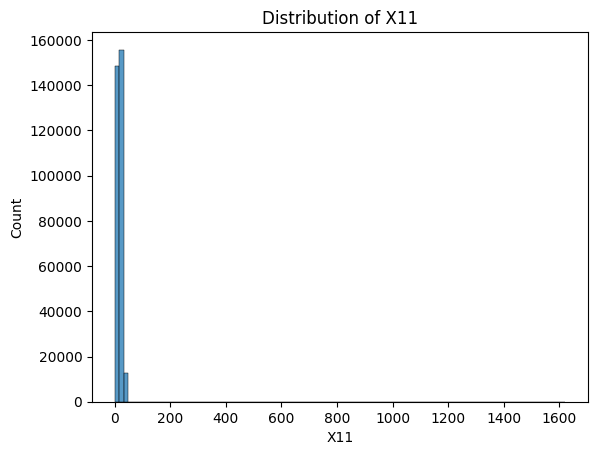

In [94]:
# histogram 
sns.histplot(features['X11'], bins=100)
plt.title('Distribution of X11')
plt.show()

Yeah evidently, because of the outlier, there is a heavy right skew. 

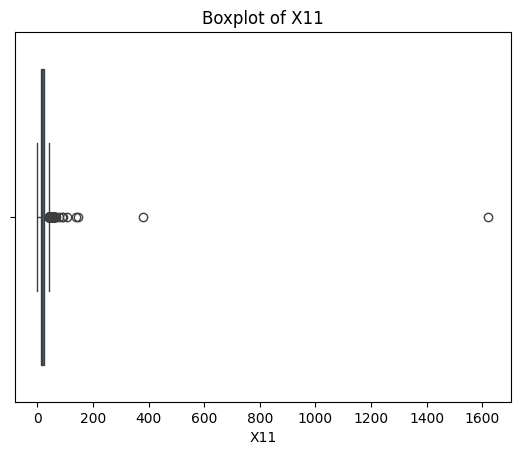

In [95]:
# boxplot
sns.boxplot(x=features['X11'])
plt.title('Boxplot of X11')
plt.show()

Once again, we see heavy skewing. Which means we'll definitely have to deal with the outlier. 

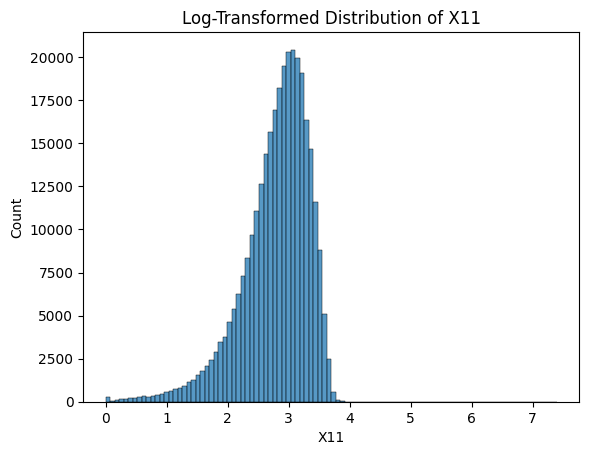

In [96]:
import numpy as np

log_transformed = np.log1p(features['X11'])

sns.histplot(log_transformed, bins=100)
plt.title('Log-Transformed Distribution of X11')
plt.show()

We see a major improvement after the log transformation and the data is much more symmetrical now. 

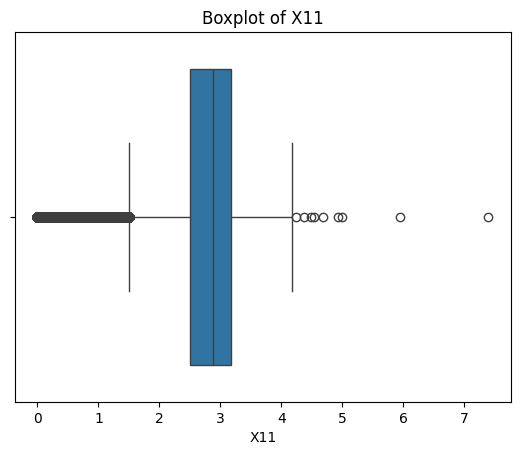

In [97]:
# boxplot
sns.boxplot(x=log_transformed)
plt.title('Boxplot of X11')
plt.show()

Boxplot also indicates improvement. 

Let's check how 'X11' relates with the target 'Y'

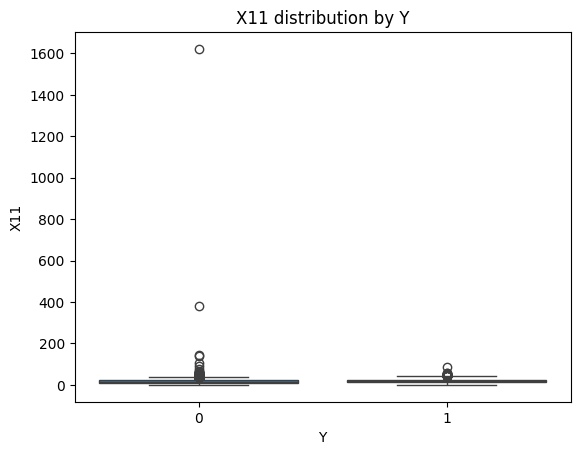

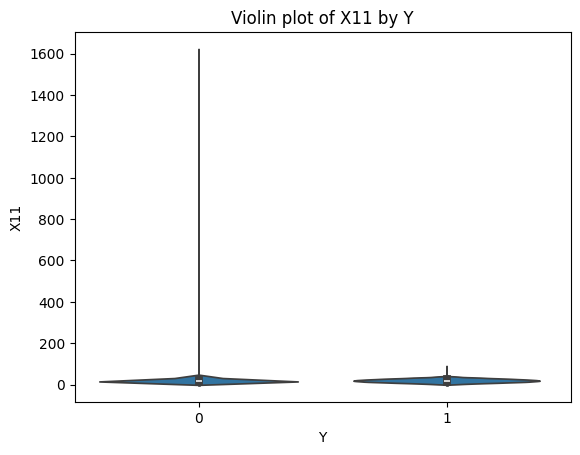

In [98]:
sns.boxplot(x=target, y=features['X11'])
plt.title('X11 distribution by Y')
plt.show()

sns.violinplot(x=target, y=features['X11'])
plt.title('Violin plot of X11 by Y')
plt.show()

Once again, the plots are heavily skewed. Let us check with the log transformation

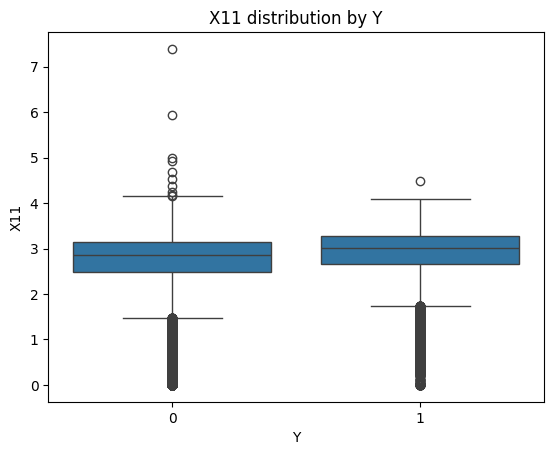

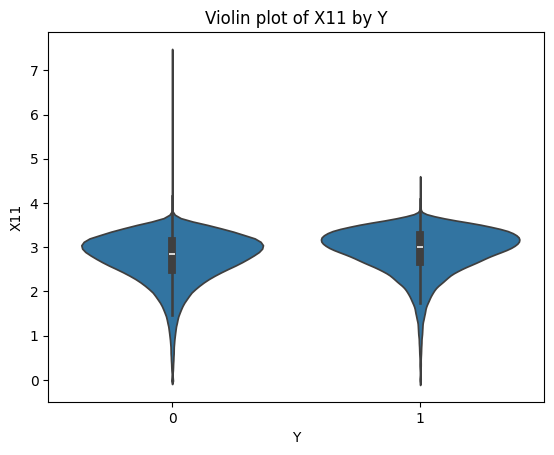

In [99]:
sns.boxplot(x=target, y=log_transformed)
plt.title('X11 distribution by Y')
plt.show()

sns.violinplot(x=target, y=log_transformed)
plt.title('Violin plot of X11 by Y')
plt.show()

The spread for Y=0 and Y=1 seems to be quite similar. There is a quite large overlap between the two classes and hence it seems like 'X11' may not be a strong predictor.

# X12

In [100]:
features['X12'].describe()

count    316824.000000
mean         11.311974
std           5.141122
min           0.000000
25%           8.000000
50%          10.000000
75%          14.000000
max          90.000000
Name: X12, dtype: float64

Seems like 'X12' is another continous variable. It looks like it may also have outliers since the mean is around 11.3 but the max is 90. 

In [101]:
features['X12'].isnull().sum()

0

In [102]:
features['X12'].isna().sum()

0

No missing or Nan values

Let's have a look at the distribution of 'X12'

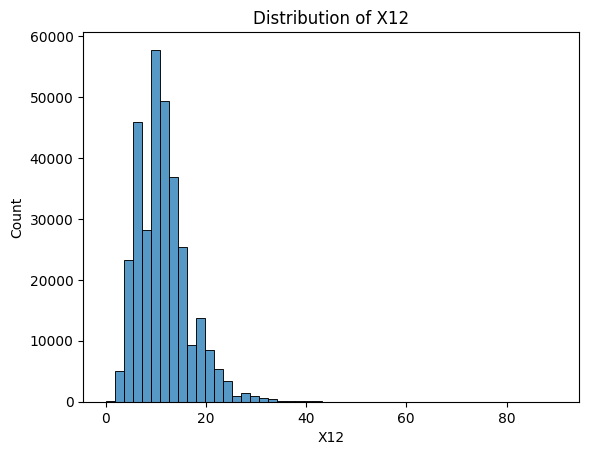

In [103]:
sns.histplot(features['X12'], bins=50)
plt.title("Distribution of X12")
plt.show()

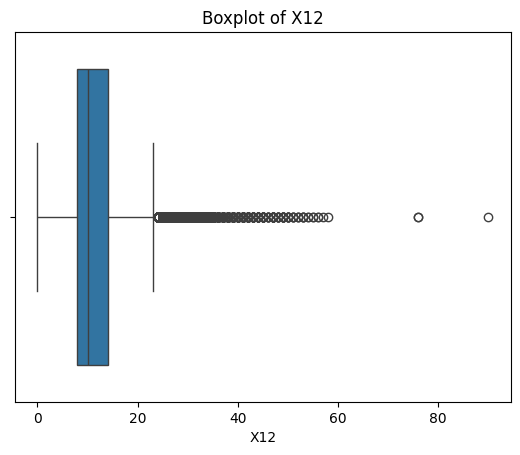

In [104]:
sns.boxplot(x=features['X12'])
plt.title("Boxplot of X12")
plt.show()

Seems like 'X11', 'X12' also has noticeable right skew however the outliers are not nearly as extreme. 

Let's apply a log transformation, same as before

In [105]:
# log1p returns log(1+x) and is retains accuracy when numbers are close to 0.
x12_log_transformed = np.log1p(features['X12'])

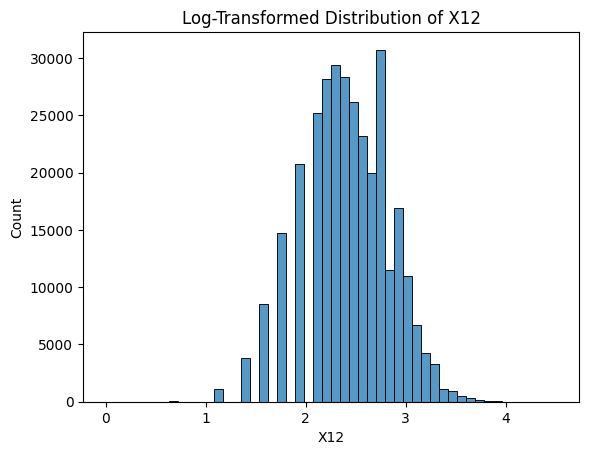

In [106]:
sns.histplot(x12_log_transformed, bins=50)
plt.title("Log-Transformed Distribution of X12")
plt.show()

We see there is a clear improvement and a major reduction in skewness. 

Let's have a look at the relationship 'X12' has with the target 'Y'

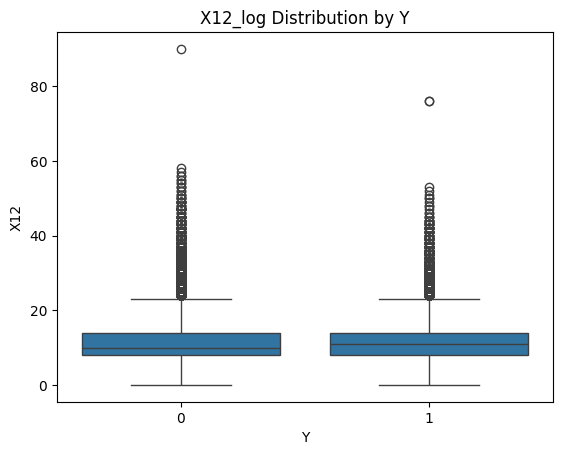

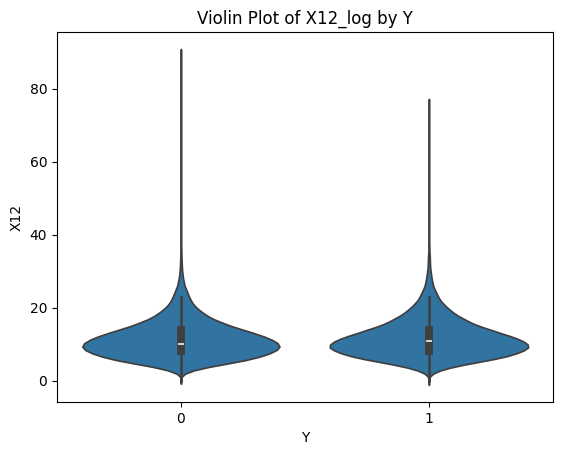

In [107]:
sns.boxplot(x=target, y=features['X12'])
plt.title("X12_log Distribution by Y")
plt.show()

sns.violinplot(x=target, y=features['X12'])
plt.title("Violin Plot of X12_log by Y")
plt.show()

The plots are not too bad but they are definitely skewed. Let's have look with the log transformation. 

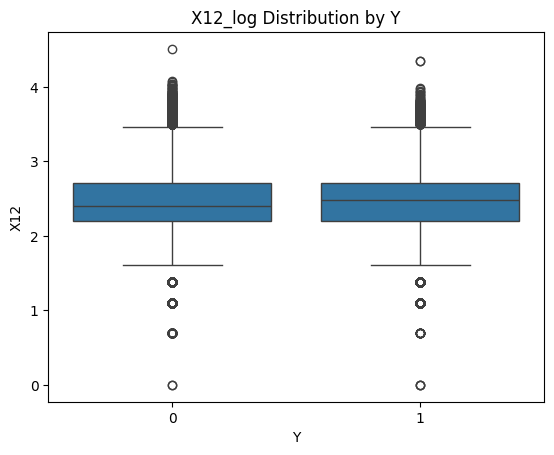

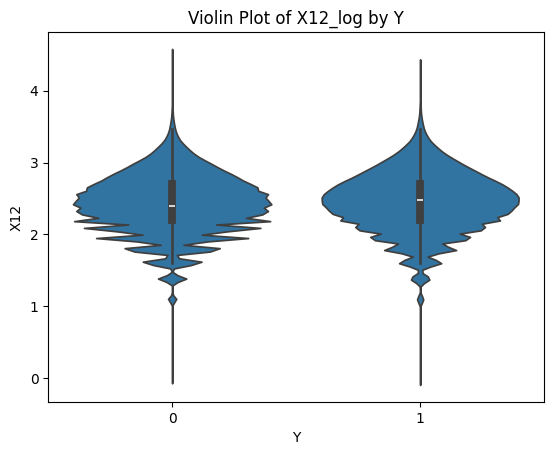

In [108]:
sns.boxplot(x=target, y=x12_log_transformed)
plt.title("X12_log Distribution by Y")
plt.show()

sns.violinplot(x=target, y=x12_log_transformed)
plt.title("Violin Plot of X12_log by Y")
plt.show()

Evidently, the distributions are near identical for y=0 and y=1 even after the log transformation. Overall, 'X12' seems like a poor predictor.

# X13

In [109]:
features['X13'].describe()

count    316824.000000
mean          0.178206
std           0.535613
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          86.000000
Name: X13, dtype: float64

In [110]:
features['X13']

0         0.0
1         1.0
2         0.0
3         0.0
4         1.0
         ... 
316819    0.0
316820    0.0
316821    1.0
316822    2.0
316823    0.0
Name: X13, Length: 316824, dtype: float64

In [111]:
features['X13'].unique()

array([ 0.,  1.,  2.,  5.,  3.,  4.,  7., 11.,  6., 10.,  8.,  9., 86.,
       19., 12., 13., 40., 24., 17.])

In [112]:
features['X13'].value_counts()

X13
0.0     270578
1.0      39885
2.0       4336
3.0       1198
4.0        426
5.0        196
6.0         99
7.0         45
8.0         25
10.0        10
9.0          9
11.0         5
12.0         3
13.0         3
19.0         2
86.0         1
40.0         1
24.0         1
17.0         1
Name: count, dtype: int64

Seems like 'X13' takes on a variety of values but is majorily dominated by 0s. 

Let's take a look at the distribution.

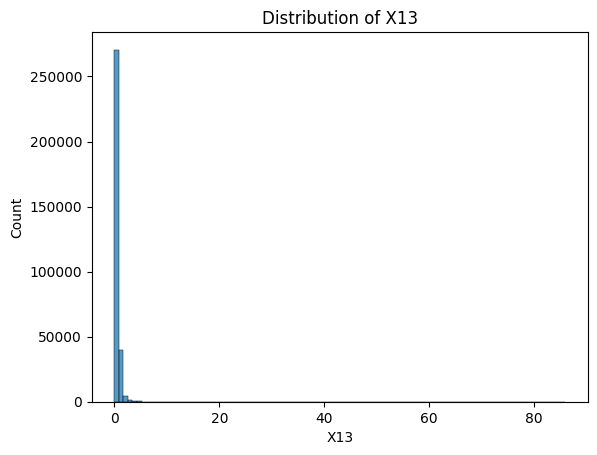

In [113]:
sns.histplot(features['X13'], bins=100)
plt.title("Distribution of X13")
plt.show()

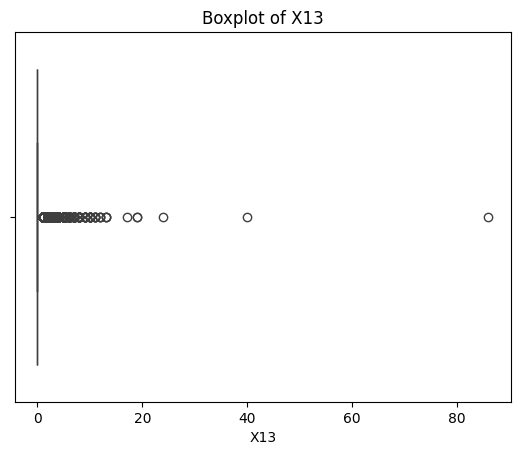

In [114]:
sns.boxplot(x=features['X13'])
plt.title("Boxplot of X13")
plt.show()

We see there is some very heavy skewness. Which makes sense as we confirmed earlier that 0 is the dominating value. 

In [115]:
features['X13'].isna().sum()

0

Let's check the relationship of 'X13' with 'Y'.

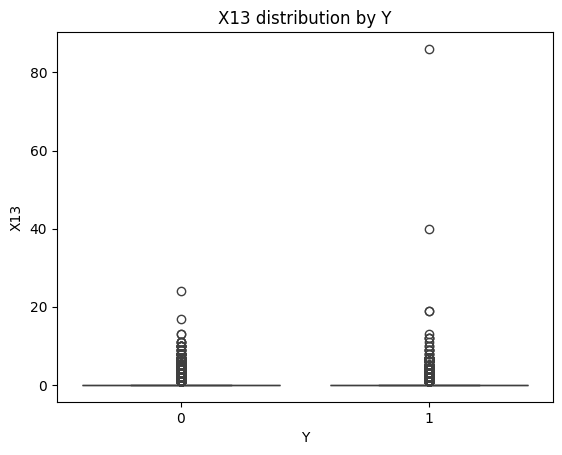

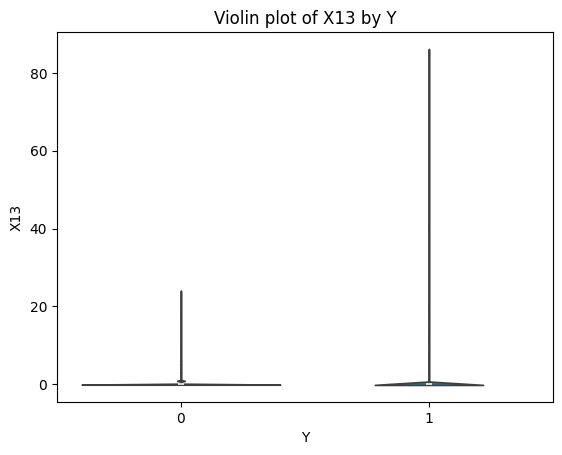

In [116]:
sns.boxplot(x=target, y=features['X13'])
plt.title("X13 distribution by Y")
plt.show()

sns.violinplot(x=target, y=features['X13'])
plt.title("Violin plot of X13 by Y")
plt.show()

Evidently, there is very heavy skewness. 

Since the zeros heavily distort and dominate the plots, let's visualise the data without the zeros.

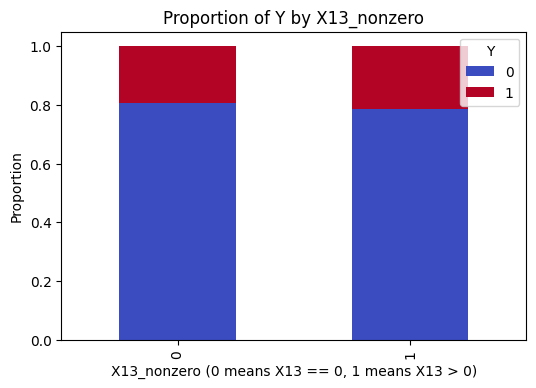

In [117]:
x13_nonzero = (features['X13'] > 0).astype(int)

# create the crosstab
proportions = pd.crosstab(x13_nonzero, target, normalize='index')

# plot it
proportions.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(6,4))
plt.title("Proportion of Y by X13_nonzero")
plt.xlabel("X13_nonzero (0 means X13 == 0, 1 means X13 > 0)")
plt.ylabel("Proportion")
plt.legend(title='Y', loc='upper right')
plt.show()

It seems like the proportions are nearly identical regardless of whether 'X13' is zero or nonzero. Which means 'X13' is a poor predictor and the presence of a non-zero value in X13 does not meaningfully affect the probability of Y = 1. 

# X14

In [118]:
features['X14'].describe()

count    3.168240e+05
mean     1.585640e+04
std      2.079702e+04
min      0.000000e+00
25%      6.023000e+03
50%      1.118550e+04
75%      1.960900e+04
max      1.743266e+06
Name: X14, dtype: float64

In [120]:
features['X14'].value_counts()

X14
0.0         1682
5655.0        36
6077.0        31
3953.0        31
7679.0        30
            ... 
42303.0        1
121354.0       1
26753.0        1
37632.0        1
56192.0        1
Name: count, Length: 52032, dtype: int64

In [121]:
features['X14'].isna().sum()

0

Looks there are no missing values. Furthermore, does not seem like there are any major outliers. 

Let's have a look at the distribution

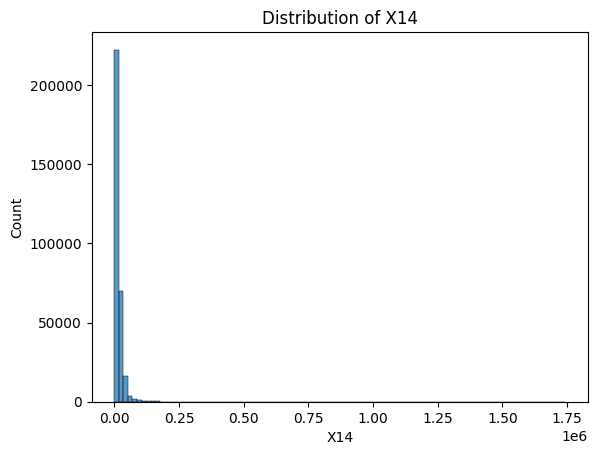

In [123]:
sns.histplot(features['X14'], bins=100)
plt.title("Distribution of X14")
plt.show()

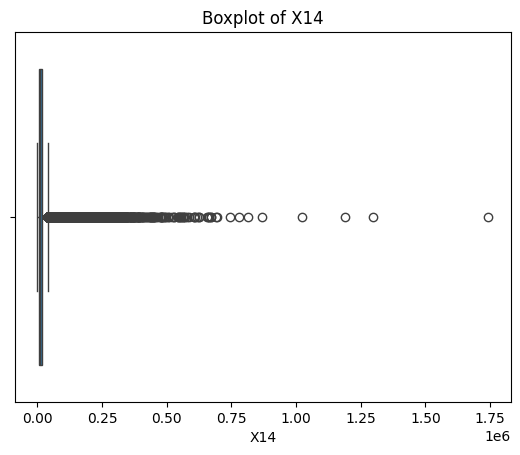

In [124]:
sns.boxplot(x=features['X14'])
plt.title('Boxplot of X14')
plt.show()

Once again, evidently, there is heavy skewing. 

Let's apply a log transformation. 

In [125]:
x14_log_transformed = np.log1p(features['X14'])

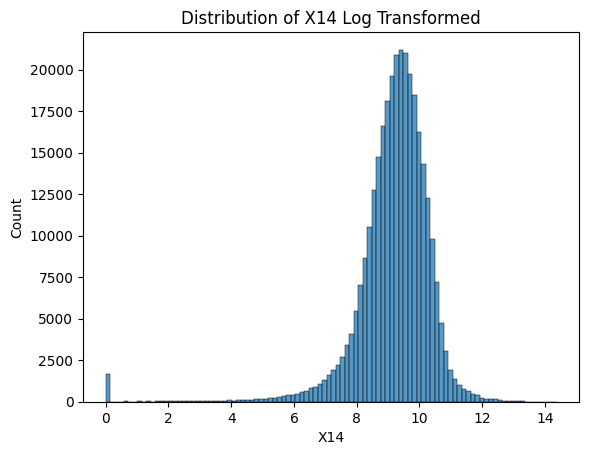

In [127]:
sns.histplot(x14_log_transformed, bins=100)
plt.title("Distribution of X14 Log Transformed")
plt.show()

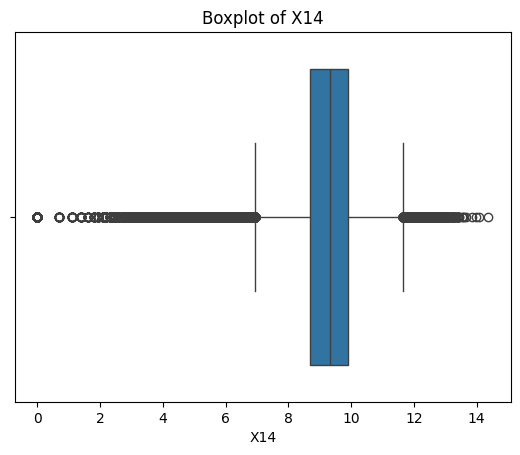

In [128]:
sns.boxplot(x=x14_log_transformed)
plt.title('Boxplot of X14')
plt.show()

Once again, there is a major improvement, and the data is a lot more symmetrical now. 

Let's take a look at the relationship between 'X14' and 'Y'.

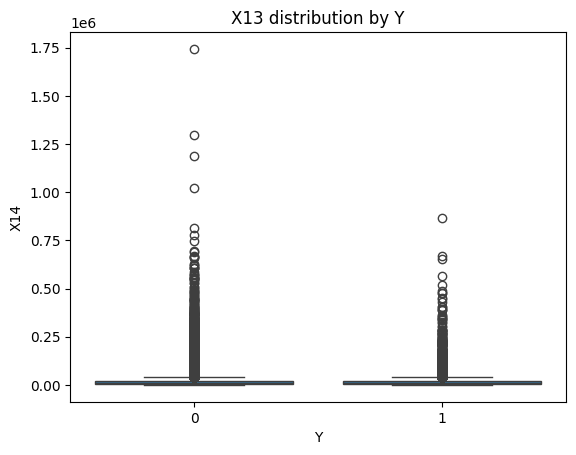

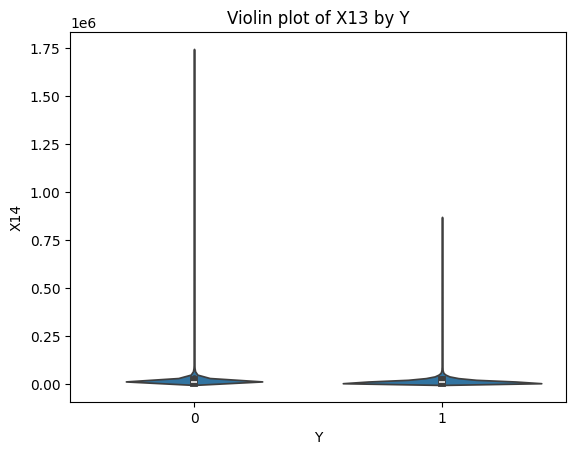

In [130]:
sns.boxplot(x=target, y=features['X14'])
plt.title("X13 distribution by Y")
plt.show()

sns.violinplot(x=target, y=features['X14'])
plt.title("Violin plot of X13 by Y")
plt.show()

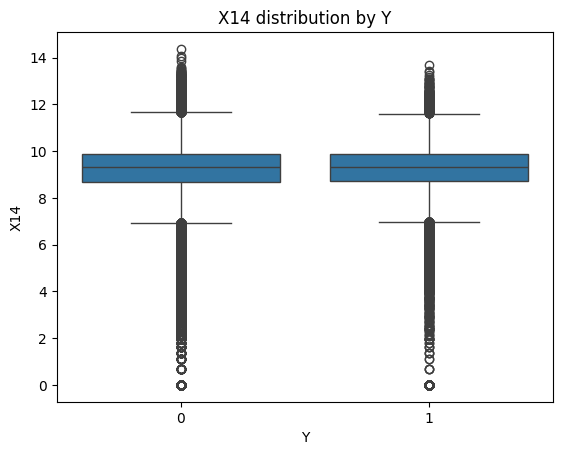

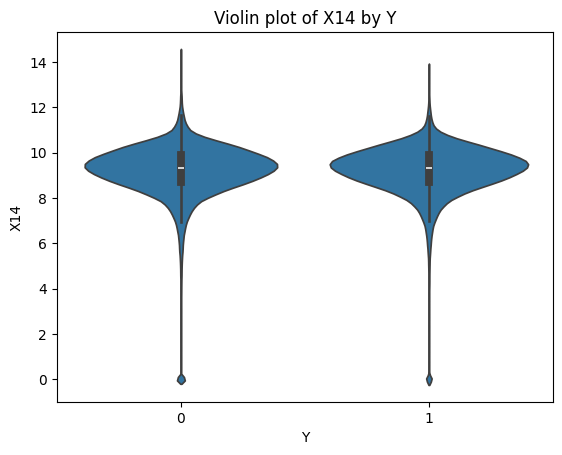

In [132]:
sns.boxplot(x=target, y=x14_log_transformed)
plt.title("X14 distribution by Y")
plt.show()

sns.violinplot(x=target, y=x14_log_transformed)
plt.title("Violin plot of X14 by Y")
plt.show()

As such, it looks like 'X14' has poor predictive power.

# X15

In [133]:
features['X15'].describe()

count    316594.000000
mean         53.780322
std          24.428614
min           0.000000
25%          35.800000
50%          54.800000
75%          72.900000
max         153.000000
Name: X15, dtype: float64

In [134]:
features['X15'].isna().sum()

230

Looks like there are 230 missing values. 

In [138]:
features['X15'].isnull().sum()

230

Let's inspect the distribution with and without the missing values

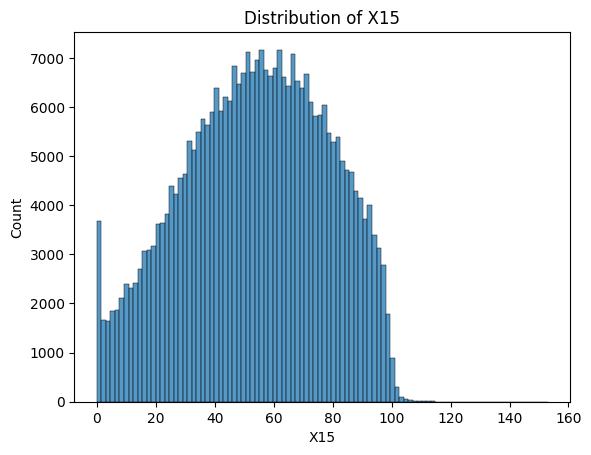

In [139]:
sns.histplot(features['X15'], bins=100)
plt.title("Distribution of X15")
plt.show()

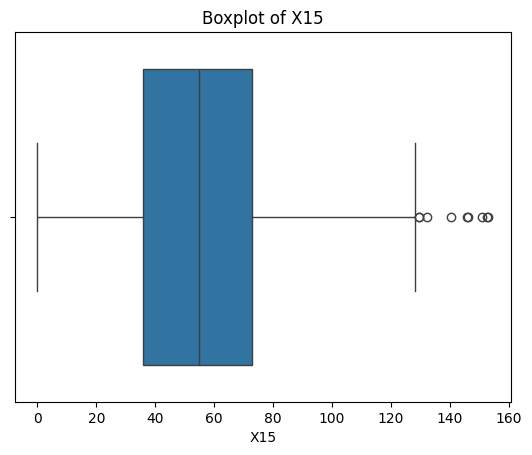

In [141]:
sns.boxplot(x=features['X15'])
plt.title('Boxplot of X15')
plt.show()

We see overall the distribution is quite symmetrical with some slight skewness. Let's have a look without the missing values. 

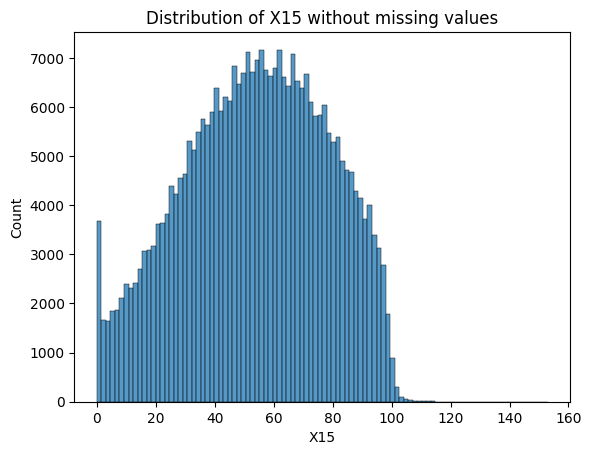

In [142]:
sns.histplot(features['X15'].dropna(), bins=100)
plt.title("Distribution of X15 without missing values")
plt.show()

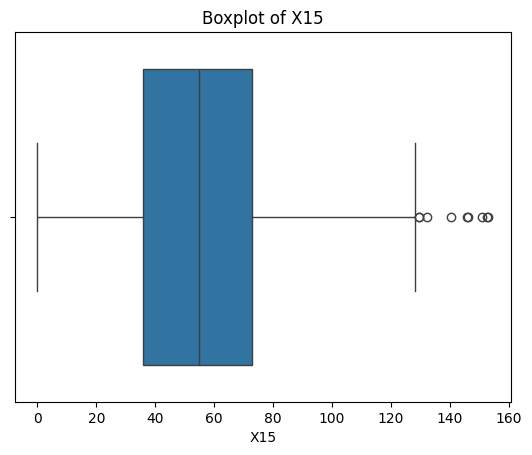

In [143]:
sns.boxplot(x=features['X15'].dropna())
plt.title('Boxplot of X15')
plt.show()

Looks like dropping the missing values, did not change the distribution at all. 

Let's fill in the missing values and visualise the relationship between 'X15' and 'Y'

In [144]:
x15_filled = features['X15'].fillna(features['X15'].mean())

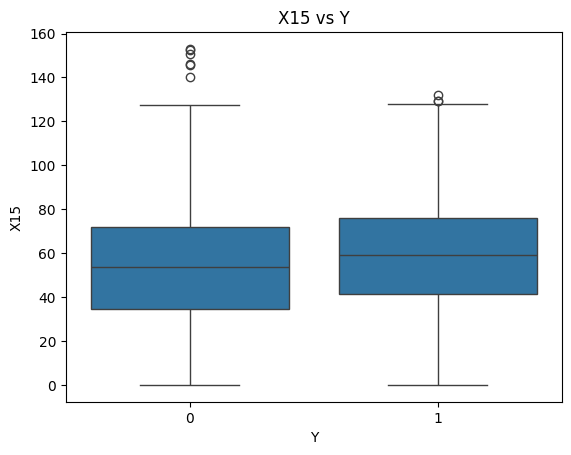

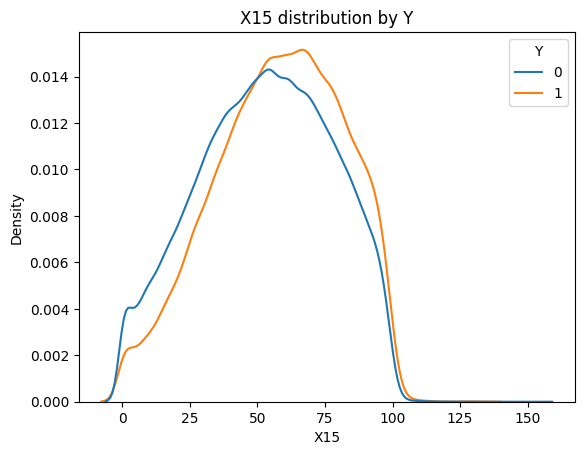

In [145]:
sns.boxplot(x=target, y=x15_filled)
plt.title("X15 vs Y")
plt.show()

sns.kdeplot(x=x15_filled, hue=target, common_norm=False)
plt.title("X15 distribution by Y")
plt.show()

Looks like the boxplots for Y = 0 and Y = 1 are fairly close with Y = 1 slightly higher. Overall, it seems like X15 has poor predictive power. 

# X16

In [146]:
features.head(20)

,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19
0,f,3.50,6.0,0.0,5514.0,19.5,20.0,b,a,NaN
1,b,14.03,14.0,1.0,5808.0,75.4,36.0,a,a,1.0
2,d,0.89,12.0,0.0,449.0,2.0,22.0,b,a,NaN
3,b,32.42,14.0,0.0,6557.0,23.9,26.0,a,a,0.0
4,b,9.91,11.0,1.0,17499.0,53.2,29.0,b,a,0.0
5,d,3.67,4.0,0.0,5734.0,48.6,17.0,b,a,NaN
6,b,9.76,13.0,0.0,120956.0,35.5,32.0,b,a,3.0
7,c,11.58,16.0,0.0,11849.0,32.7,23.0,b,a,0.0
8,c,7.55,6.0,1.0,6135.0,73.0,17.0,a,a,3.0
9,b,24.44,8.0,0.0,12954.0,85.8,13.0,b,a,2.0


In [147]:
features['X16'].describe()

count    316824.000000
mean         25.417932
std          11.894787
min           2.000000
25%          17.000000
50%          24.000000
75%          32.000000
max         151.000000
Name: X16, dtype: float64

Looks like 'X16' is a continuous variable with some extreme outliers. 

In [148]:
features['X16'].isna().sum()

0

No missing values

Let's take a look at the distribution. 

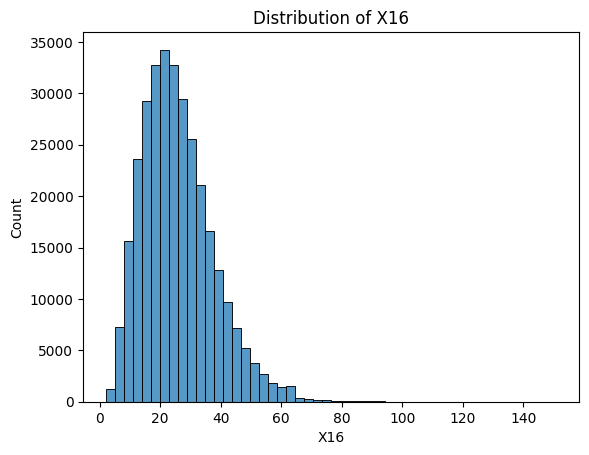

In [151]:
sns.histplot(features['X16'], bins=50)
plt.title("Distribution of X16")
plt.show()

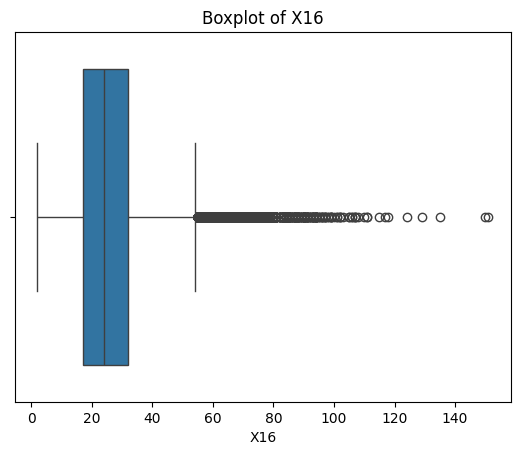

In [150]:
sns.boxplot(x=features['X16'])
plt.title('Boxplot of X16')
plt.show()

The data is definitely right skewed. Let's apply a log transformation

In [152]:
x16_log_transformed = np.log1p(features['X16'])

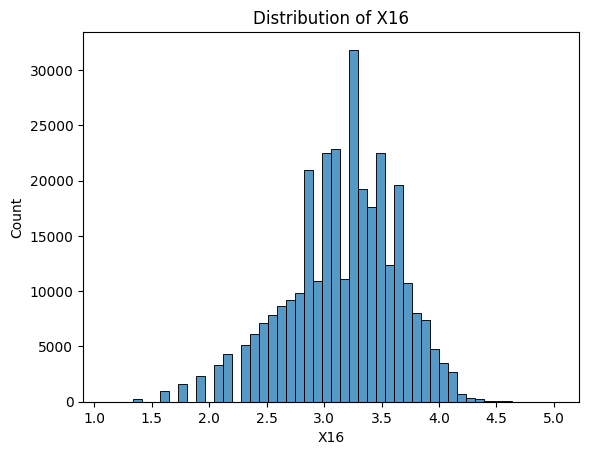

In [153]:
sns.histplot(x16_log_transformed, bins=50)
plt.title("Distribution of X16")
plt.show()

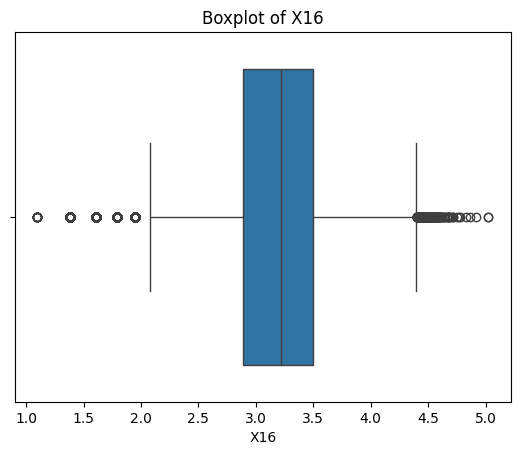

In [154]:
sns.boxplot(x=x16_log_transformed)
plt.title('Boxplot of X16')
plt.show()

The data seems to be more symmetrical now. 

Let's assess the relationship between 'X16' and 'Y'.

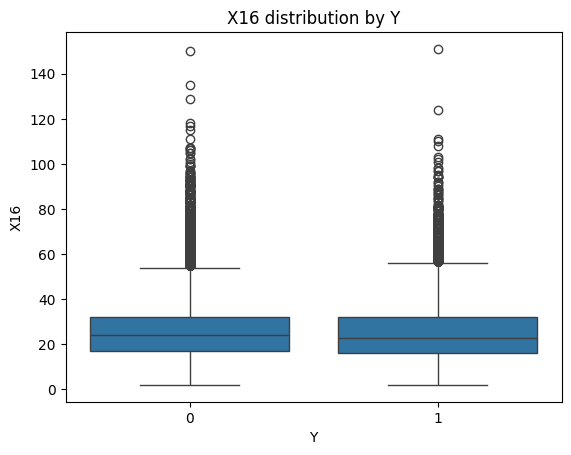

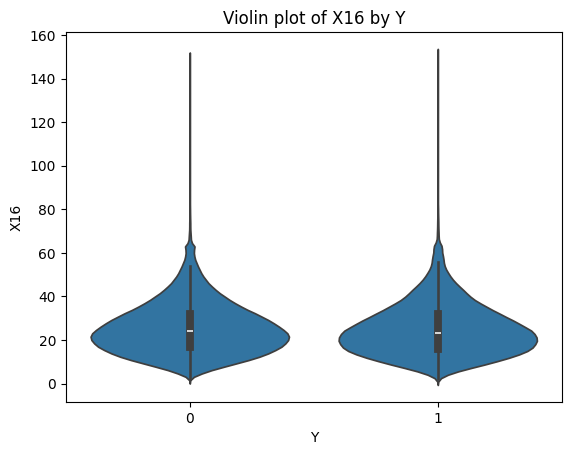

In [155]:
sns.boxplot(x=target, y=features['X16'])
plt.title("X16 distribution by Y")
plt.show()

sns.violinplot(x=target, y=features['X16'])
plt.title("Violin plot of X16 by Y")
plt.show()

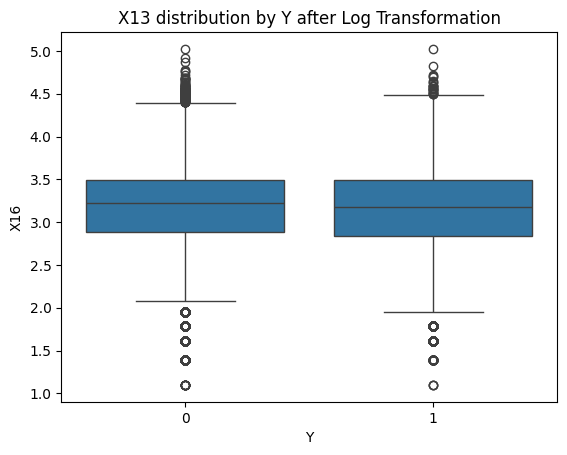

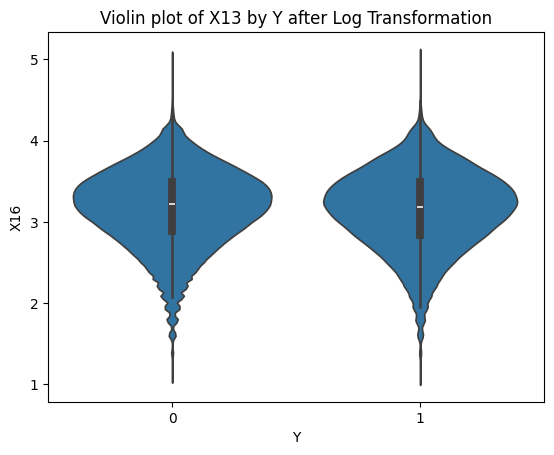

In [156]:
sns.boxplot(x=target, y=x16_log_transformed)
plt.title("X13 distribution by Y after Log Transformation")
plt.show()

sns.violinplot(x=target, y=x16_log_transformed)
plt.title("Violin plot of X13 by Y after Log Transformation")
plt.show()

We see the distributions are near identical for Y = 0 and Y = 1 which is indicative of a poor predictor variable. 

# X17

In [157]:
features['X17'].describe()

count     316824
unique         2
top            b
freq      190475
Name: X17, dtype: object

In [158]:
features['X17'].isna().sum()

0

In [159]:
features['X17'].value_counts()

X17
b    190475
a    126349
Name: count, dtype: int64

Let's look at the distributions

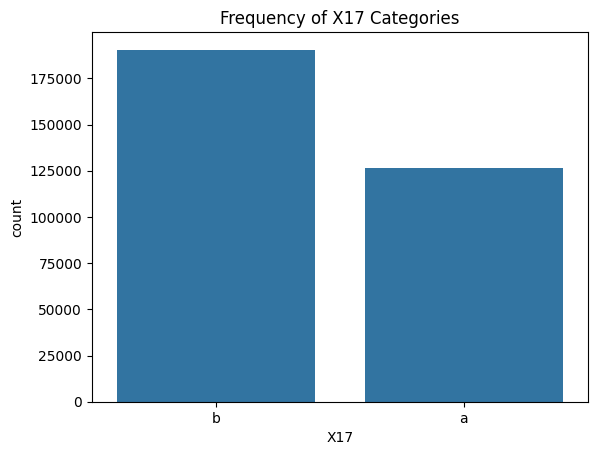

In [160]:
# frequency of each category
x17_freq = features['X17'].value_counts()

# Bar plot
sns.countplot(data=features, x='X17', order=x17_freq.index)
plt.title('Frequency of X17 Categories')
plt.show()

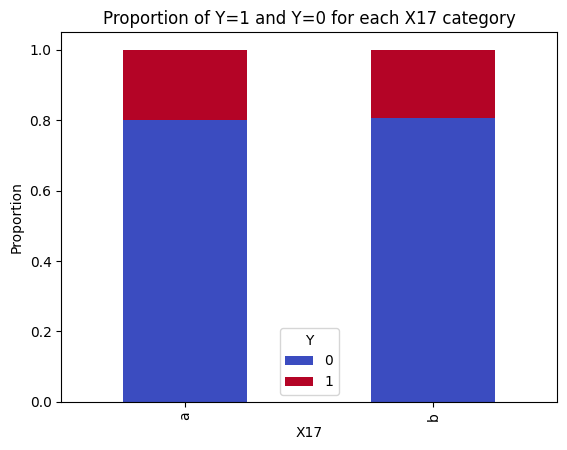

In [161]:
ct = pd.crosstab(features['X17'], target, normalize='index')

ct.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Proportion of Y=1 and Y=0 for each X17 category')
plt.ylabel('Proportion')
plt.show()

Seems like the proportions of y = 0 and y = 1 for each 'X17' category is roughly equal. Meaning 'X17' isn't a dominant predictor.  

# X18

In [164]:
features['X18'].describe()

count     316824
unique         3
top            a
freq      316273
Name: X18, dtype: object

In [165]:
features['X18'].value_counts()

X18
a    316273
b       324
c       227
Name: count, dtype: int64

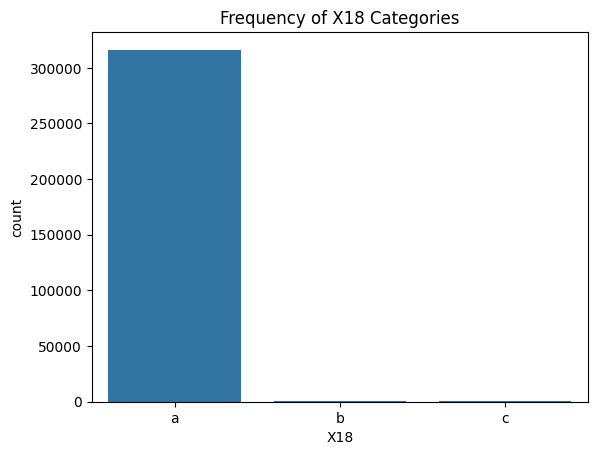

In [166]:
# frequency of each category
x18_freq = features['X18'].value_counts()

# Bar plot
sns.countplot(data=features, x='X18', order=x18_freq.index)
plt.title('Frequency of X18 Categories')
plt.show()

It is evident that X18 is super unbalanced with 'a' largely dominating. 

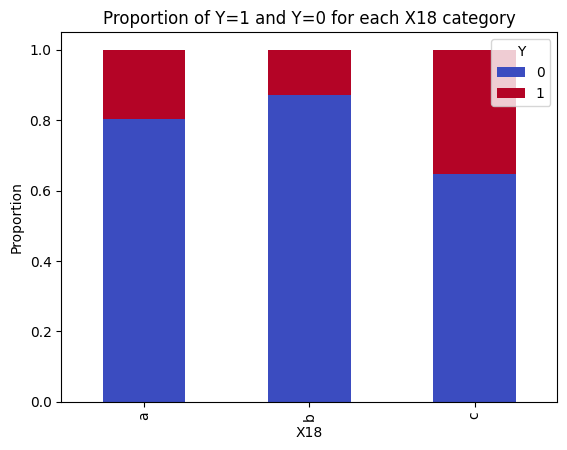

In [167]:
ct = pd.crosstab(features['X18'], target, normalize='index')

ct.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Proportion of Y=1 and Y=0 for each X18 category')
plt.ylabel('Proportion')
plt.show()

It's evident that 'b' has the highest proportion of Y=0s and 'c' has the highest proportion of Y=1s. Overall, this variable could have some predictive power especially if combined with other variables. 

# X19

In [168]:
features['X19'].describe()

count    286594.000000
mean          1.815520
std           2.150931
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          34.000000
Name: X19, dtype: float64

In [169]:
features['X19'].isna().sum()

30230

'X19' has a lot of missing values approximatley 30230. 

Let's first analyse without imputing missing values. 

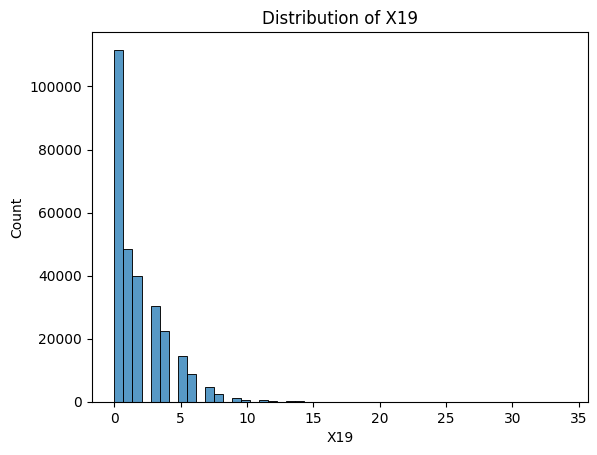

In [171]:
sns.histplot(features['X19'], bins=50)
plt.title("Distribution of X19")
plt.show()

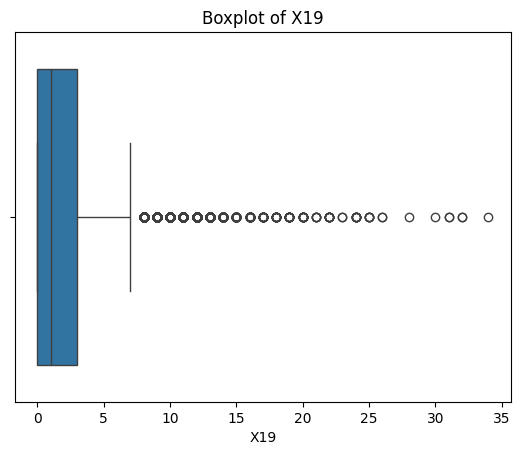

In [172]:
sns.boxplot(x=features['X19'])
plt.title('Boxplot of X19')
plt.show()

Evidently, the data is right skewed and quite significantly too. Let's check after imputing missing values. 

In [173]:
x19_filled = features['X19'].fillna(features['X19'].mean())

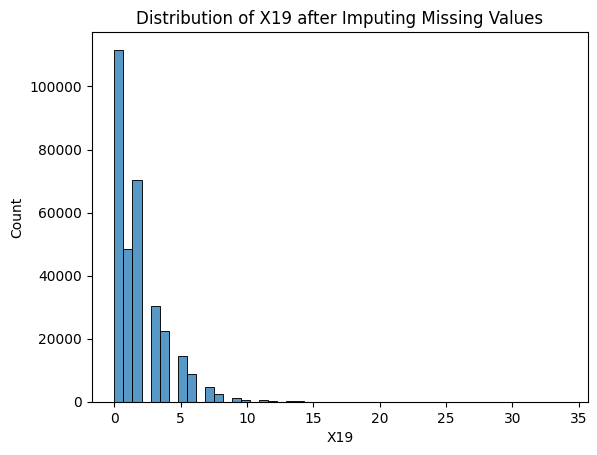

In [176]:
sns.histplot(x19_filled, bins=50)
plt.title("Distribution of X19 after Imputing Missing Values")
plt.show()

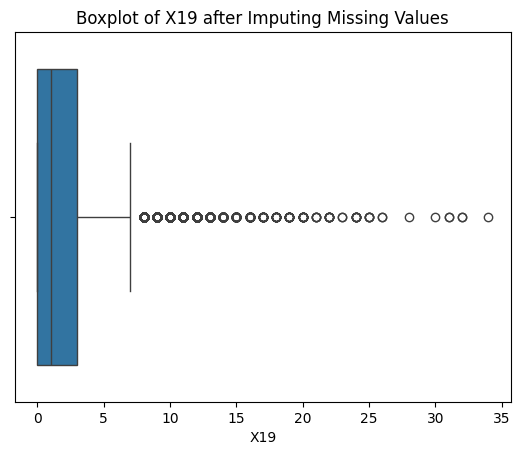

In [177]:
sns.boxplot(x=x19_filled)
plt.title('Boxplot of X19 after Imputing Missing Values')
plt.show()

Let's perform a log transformation

In [179]:
x19_log_transformed = np.log1p(x19_filled)

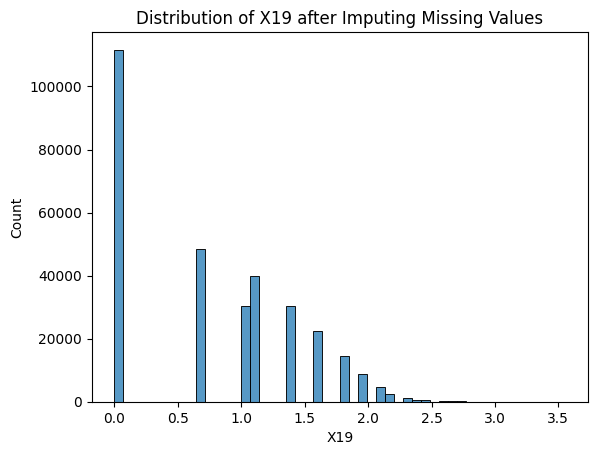

In [180]:
sns.histplot(x19_log_transformed, bins=50)
plt.title("Distribution of X19 after Imputing Missing Values")
plt.show()

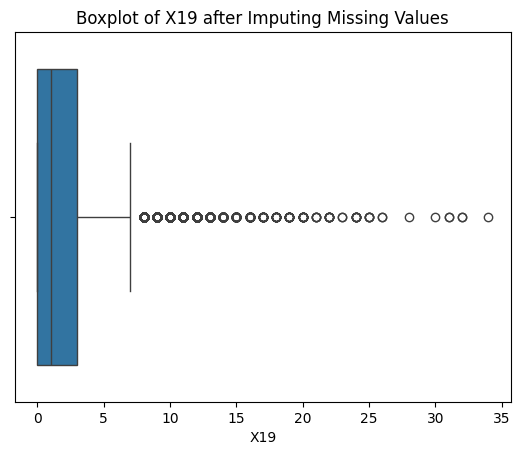

In [181]:
sns.boxplot(x=x19_filled)
plt.title('Boxplot of X19 after Imputing Missing Values')
plt.show()

So there is not much improvement after the log transformation. It actually looks sort of worse. 

Let's look at the relationships.

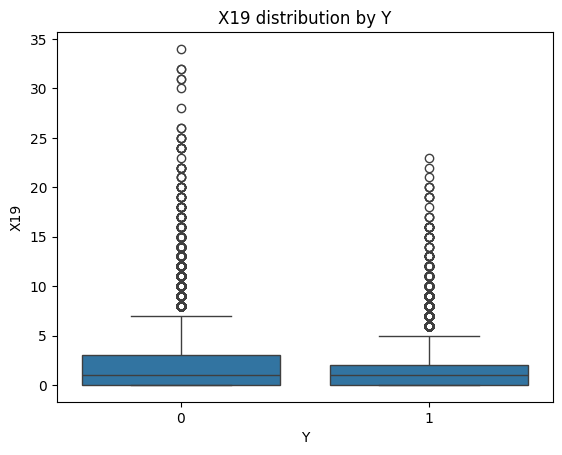

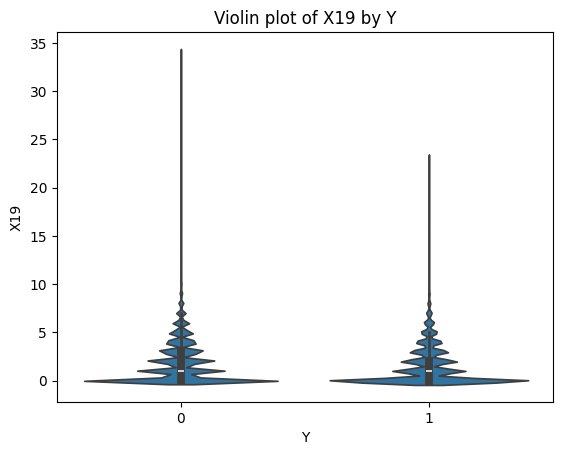

In [184]:
sns.boxplot(x=target, y=features['X19'])
plt.title("X19 distribution by Y")
plt.show()

sns.violinplot(x=target, y=features['X19'])
plt.title("Violin plot of X19 by Y")
plt.show()

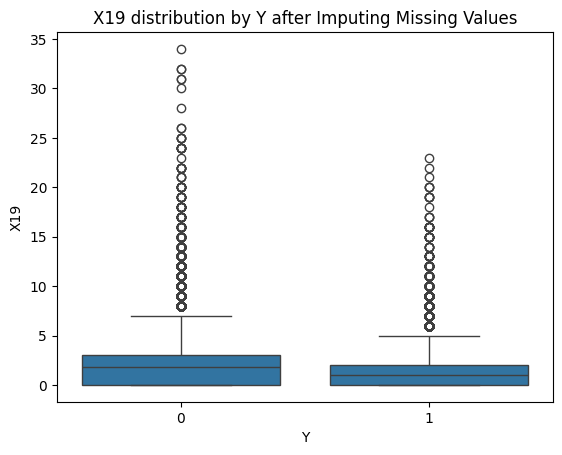

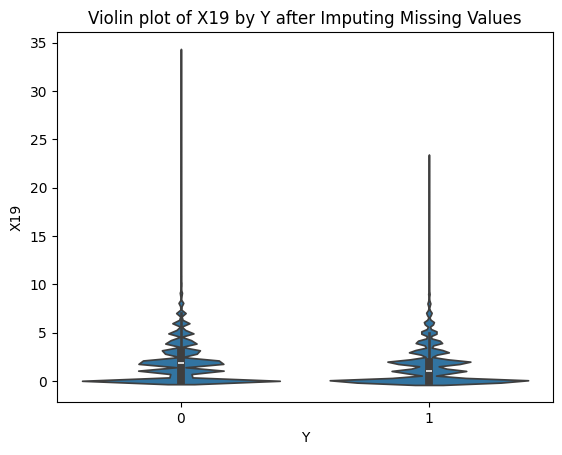

In [185]:
sns.boxplot(x=target, y=x19_filled)
plt.title("X19 distribution by Y after Imputing Missing Values")
plt.show()

sns.violinplot(x=target, y=x19_filled)
plt.title("Violin plot of X19 by Y after Imputing Missing Values")
plt.show()

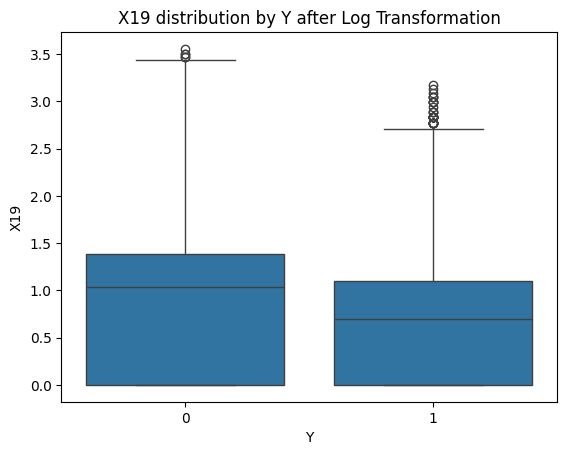

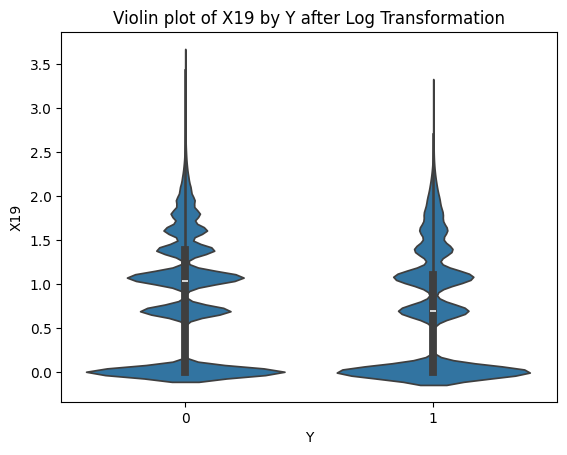

In [186]:
sns.boxplot(x=target, y=x19_log_transformed)
plt.title("X19 distribution by Y after Log Transformation")
plt.show()

sns.violinplot(x=target, y=x19_log_transformed)
plt.title("Violin plot of X19 by Y after Log Transformation")
plt.show()